# Phase 4 - Personalised Feedback Generation

**DOLPH-X Pipeline | Master 2 MIAGE**

**Description:** Generates personalised, pedagogically grounded feedback for each student. Uses a two-LLM sequential architecture: a Reasoning LLM (Phase 4a) produces a structured JSON analysis, and a Feedback Generator LLM (Phase 4b) transforms it into natural language feedback.

**Pedagogical constraints:** SDT (Deci & Ryan, 2000), TPB (Ajzen, 1991), Growth Mindset (Dweck, 2006), Hattie & Timperley (2007) Feed Up / Feed Back / Feed Forward structure.

**Input:** `outputs/validated_features.csv`

**Output:** `outputs/feedback_final.csv`

## 1. Imports and Configuration

In [3]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

os.environ['GROQ_API_KEY'] = 'XXX' 

try:
    from groq import Groq
    print('Groq import OK')
except ImportError:
    print('ERROR: Groq not installed - pip install groq')

df_validated = pd.read_csv('outputs/validated_features.csv')
print(f'validated_features.csv loaded: {len(df_validated)} rows')
print(f'Instances : {df_validated["instance_id"].nunique()}')
print(f'Profiles  : {df_validated["profil"].unique()}')

Groq import OK
validated_features.csv loaded: 105 rows
Instances : 13
Profiles  : ['E-P+' 'E+P+' 'E-P-' 'E+P-']


## 2. Feature Descriptions Dictionary

Maps raw LMS variable names to human-readable pedagogical descriptions. Sent to the LLM to improve interpretability (inspired by iLLuMinaTE, Swamy et al., 2025).

In [5]:
FEATURE_DESCRIPTIONS = {
    'COURSE_ACCESS_MINUTES'     : 'Total time spent connected to the course platform (in minutes)',
    'COURSE_ACCESS_CONNECTION'  : 'Number of login sessions to the course platform',
    'COURSE_INTERACTIONS'       : 'Number of interactions with course content (clicks, views, downloads)',
    'T_EXE_SUBMISSION_COUNT'    : 'Total number of exercise submissions across all sessions',
    'RATING_S1Q1'               : 'Grade obtained in Session 1 exercise',
    'RATING_S2Q1'               : 'Grade obtained in Session 2 exercise',
    'RATING_S3Q1'               : 'Grade obtained in Session 3 exercise',
    'RATING_S4Q1'               : 'Grade obtained in Session 4 exercise',
    'RATING_S5Q1'               : 'Grade obtained in Session 5 exercise',
    'RATING_S6Q1'               : 'Grade obtained in Session 6 exercise',
    'RATING_S7Q1'               : 'Grade obtained in Session 7 exercise',
    'RATING_S8Q1'               : 'Grade obtained in Session 8 exercise',
    'RATING_S9Q1'               : 'Grade obtained in Session 9 exercise',
    'RATING_S10Q1'              : 'Grade obtained in Session 10 exercise',
    'RATING_FINAL_EXAM'         : 'Grade obtained in the final examination',
    'S1Q1_EXE_SUBMISSION_COUNT' : 'Number of exercise submissions in Session 1',
    'S2Q1_EXE_SUBMISSION_COUNT' : 'Number of exercise submissions in Session 2',
    'S3Q1_EXE_SUBMISSION_COUNT' : 'Number of exercise submissions in Session 3',
    'S4Q1_EXE_SUBMISSION_COUNT' : 'Number of exercise submissions in Session 4',
    'S5Q1_EXE_SUBMISSION_COUNT' : 'Number of exercise submissions in Session 5',
    'S6Q1_EXE_SUBMISSION_COUNT' : 'Number of exercise submissions in Session 6',
    'S7Q1_EXE_SUBMISSION_COUNT' : 'Number of exercise submissions in Session 7',
    'S8Q1_EXE_SUBMISSION_COUNT' : 'Number of exercise submissions in Session 8',
    'S9Q1_EXE_SUBMISSION_COUNT' : 'Number of exercise submissions in Session 9',
    'S10Q1_EXE_SUBMISSION_COUNT': 'Number of exercise submissions in Session 10',
    'FE_EXE_SUBMISSION_COUNT'   : 'Number of submissions for the final exam exercise',
    'FIRST_S8Q1_EXE_SUBMISSION_day'  : 'Day of first exercise submission in Session 8',
    'FIRST_S7Q1_EXE_SUBMISSION_day'  : 'Day of first exercise submission in Session 7',
    'FIRST_S5Q1_EXE_SUBMISSION_day'  : 'Day of first exercise submission in Session 5',
    'FIRST_S3Q1_EXE_SUBMISSION_day'  : 'Day of first exercise submission in Session 3',
    'LAST_S5Q1_EXE_SUBMISSION_month' : 'Month of last exercise submission in Session 5',
    'LAST_S8Q1_EXE_SUBMISSION_second': 'Second of last submission timestamp in Session 8',
    'FIRST_COURSE_ACCESS_day'        : 'Day of first ever platform access',
    'LAST_COURSE_ACCESS_day'         : 'Day of most recent platform access',
}

def get_feature_description(feature_name):
    """Returns a human-readable description for a given LMS feature name."""
    return FEATURE_DESCRIPTIONS.get(feature_name, f'{feature_name} (LMS behavioral variable)')

print(f'Feature descriptions loaded: {len(FEATURE_DESCRIPTIONS)} entries')

Feature descriptions loaded: 34 entries


## 3. FeedbackGenerator Class

Two-LLM sequential architecture:
- **Phase 4a - Reasoning LLM:** structured JSON analysis using Chain-of-Thought prompting (Wei et al., 2022)
- **Phase 4b - Feedback Generator:** natural language feedback using role prompting, constraint-based prompting and few-shot prompting

**Prompting techniques combined (Wei et al., 2022; Brown et al., 2020):**
- Chain-of-Thought: Phase 4a instructs the LLM to reason step by step before producing the JSON output
- Role prompting: both LLMs are assigned a specific identity anchoring their tone and perspective
- Constraint-based prompting: SDT, TPB, Growth Mindset and Hattie are embedded as explicit rules
- Few-shot prompting: one validated example per profile guides the Feedback Generator on style and structure

In [7]:
class FeedbackGenerator:
    MODEL_NAME = 'openai/gpt-oss-120b'
    API_DELAY  = 8.0

    PROFILE_DESCRIPTIONS = {
        'E+P+': 'engaged and high-performing: strong connection habits and good grades',
        'E+P-': 'engaged but low-performing: regular effort but insufficient results',
        'E-P+': 'disengaged but high-performing: good grades without regular platform engagement',
        'E-P-': 'disengaged and low-performing: combined deficit in engagement and performance',
    }

    def __init__(self, df_validated):
        """
        Initialise the FeedbackGenerator.

        Args:
            df_validated : DataFrame from Phase 3 (validated_features.csv)
        """
        self.df_validated = df_validated
        self.client       = Groq(api_key=os.environ.get('GROQ_API_KEY'))
        self.reasonings   = {}
        self.feedbacks    = []

    def _get_fewshot_example(self, profil):
        examples = {
            'E-P-': """
EXAMPLE for profile E-P- (disengaged and low-performing):

[Feed Up] I want to be honest with you because you deserve it: this month, I notice you connected 5 times to the platform and submitted 3 exercises out of 10. Your average grade on sessions 4 to 6 is 34 out of 100, which is lower than session 1 where you scored 58. That score of 58 tells me something important: the potential is there, it just needs to be reactivated.

[Feed Back] Think of a runner who trains less and less each week: performance drops not from lack of talent, but from lack of consistency. That is exactly what your data is telling me. Is there something right now that is making it harder for you to connect more regularly?

[Feed Forward] I am not going to ask you to change everything at once. Here is something simple and achievable: connect 3 times this week and submit the exercises for sessions 7 and 8 before Friday. It does not matter if your solution is not perfect. By comparing your answers with the corrections, you will identify your mistakes and use them as a foundation to improve. You can absolutely do this.
""",
            'E+P-': """
EXAMPLE for profile E+P- (engaged but low-performing):

[Feed Up] I can see that you connect to the platform regularly, and I want you to know that is a real strength that many students do not have. However, your grades in sessions 5 and 6 show that something is blocking the transformation of that effort into results. Do not get discouraged, you are already on the right track in terms of engagement. What I would like to suggest now is to work on the quality of what you produce.

[Feed Back] Think of someone who trains a lot but with a technique that is not quite right: the effort is genuine but needs to be redirected to be effective. This is not a motivation problem, it is a method problem. Do you take time to review the corrections after each submission?

[Feed Forward] Here is a concrete suggestion: for each exercise you submit this week, spend 10 minutes comparing your solution with the correction and identify one specific mistake not to repeat. Just one. This simple habit of active revision gradually transforms effort into genuine understanding, and results will follow.
""",
            'E-P+': """
EXAMPLE for profile E-P+ (disengaged but high-performing):

[Feed Up] I genuinely feel that you have a strong grasp of this course, and your academic results clearly show it. I want to acknowledge that first, because it is not something everyone achieves. However, I also notice that your platform connection level is quite low, and I think it is worth talking about. This imbalance could unfortunately penalise you in future sessions where consistency and regular practice matter more.

[Feed Back] Think of a good swimmer who never warms up before jumping in: it works well for a while, until one day it does not. Your current strong grades are real, but they carry a hidden risk: advanced sessions require more regular practice for concepts to truly consolidate over time. Are you aware of that risk?

[Feed Forward] Here is what I suggest, and it is genuinely achievable: try to connect at least 2 more times than usual this week to browse the resources for sessions 7 and 8. This small adjustment, even modest, will help you maintain your strong performance, revisit concepts to anchor them more deeply, and reduce the risk of a late drop in engagement.
""",
            'E+P+': """
EXAMPLE for profile E+P+ (engaged and high-performing):

[Feed Up] I can see that you combine consistency and strong performance, and I want you to know that is a genuinely excellent student profile. Your frequent connections and good grades show that your way of working is effective and suits you well. This is something you built for yourself.

[Feed Back] Your consistency is your greatest asset, and it is a skill that many other students struggle to develop. Like a musician who practises every single day, the steadiness of your engagement reflects directly and naturally in your results. Keep going, because you are on the right path.

[Feed Forward] To go even further, I would like to propose a small challenge that might surprise you: try this week to help a classmate on an exercise they find difficult. Explaining things to someone else, putting into words what you know, is the most powerful way to consolidate your own understanding and discover areas you thought you had mastered but will understand even better afterwards.
"""
        }
        return examples.get(profil, examples['E-P-'])

    def _build_reasoning_prompt(self, student_data):
        features_str = '\n'.join([
            f"  - {f['feature']}: confidence={f['confidence_score']:.2f} "
            f"| {get_feature_description(f['feature'])}"
            f"{'  [MAIN LEVER]' if f.get('is_main', False) else ''}"
            for f in student_data['features']
        ])

        profile_desc = self.PROFILE_DESCRIPTIONS.get(
            student_data['profil'], 'unknown profile'
        )

        return f"""You are an educational data analyst specialised in student behaviour analysis.

STUDENT PROFILE:
- Profile: {student_data['profil']} ({profile_desc})
- Model: {student_data['model']}
- Instance ID: {student_data['instance_id']}

VALIDATED XAI FEATURES (sorted by confidence score):
{features_str}

Think step by step before producing the JSON (Chain-of-Thought, Wei et al. 2022):
- Step 1: Identify which feature has the highest confidence score and what it reveals about this student.
- Step 2: Connect this feature to the student profile {student_data['profil']} and explain the behavioural pattern.
- Step 3: Identify one concrete strength and one realistic obstacle for this specific student.
- Step 4: Derive one specific, measurable, autonomy-supportive action from steps 1 and 2.
          Use "suggest", "encourage", "try" - never "require", "must" or "implement mandatory".

Then respond ONLY with valid JSON:
{{
  "main_cause": "...",
  "obstacle": "...",
  "strength": "...",
  "action": "..."
}}"""

    def _get_reasoning(self, student_data):
        prompt = self._build_reasoning_prompt(student_data)
        try:
            response = self.client.chat.completions.create(
                model=self.MODEL_NAME,
                messages=[
                    {
                        'role'   : 'system',
                        'content': 'You are an educational analyst. Respond ONLY with valid JSON. No markdown. No text outside JSON.'
                    },
                    { 'role': 'user', 'content': prompt }
                ],
                temperature=0.1,
                max_tokens=2000,
            )
            raw = response.choices[0].message.content.strip()
            if '```json' in raw:
                raw = raw.split('```json')[1].split('```')[0].strip()
            elif '```' in raw:
                raw = raw.split('```')[1].split('```')[0].strip()
            if '{' in raw and '}' in raw:
                raw = raw[raw.index('{'):raw.rindex('}')+1]
            return json.loads(raw)
        except Exception as e:
            print(f'\n    Reasoning LLM error: {e}')
            return None

    def _build_feedback_prompt(self, student_data, reasoning):
        fewshot      = self._get_fewshot_example(student_data['profil'])
        profile_desc = self.PROFILE_DESCRIPTIONS.get(student_data['profil'], 'unknown profile')

        return f"""You are a supportive, warm pedagogical tutor who genuinely believes every student can progress.
You write personalised feedback for online Python course students.

STUDENT CONTEXT:
- Profile: {student_data['profil']} ({profile_desc})
- Main behavioural cause: {reasoning.get('main_cause', 'N/A')}
- Likely obstacle: {reasoning.get('obstacle', 'N/A')}
- Strength to build upon: {reasoning.get('strength', 'N/A')}
- Recommended action: {reasoning.get('action', 'N/A')}

MANDATORY STRUCTURE (Hattie & Timperley, 2007):
1. Feed Up: describe the current situation with factual data. 2-3 sentences.
2. Feed Back: explain what led to this situation. Include one analogy. Ask one question. 2-3 sentences.
3. Feed Forward: give one specific, measurable action. Mention a realistic outcome. 2-3 sentences.

STRICT CONSTRAINTS:

[SDT - Self-Determination Theory, Deci & Ryan 2000]
- Never use directive language (no "you must", "you have to")
- Use autonomy-supportive phrasing ("you could try", "I would suggest")
- Acknowledge the student's situation before recommending actions

[TPB - Theory of Planned Behavior, Ajzen 1991]
- Recommend ONLY actions the student can concretely control
- Be specific: not "work more" but "submit exercise S7 before Friday"
- Make the action feel achievable, not overwhelming

[GROWTH MINDSET - Dweck 2006]
- NEVER use fixed-mindset language ("you are not cut out for", "you are bad at")
- Always frame difficulty as temporary and surmountable
- Attribute progress to effort and strategy, not innate ability

EXAMPLE OF IDEAL FEEDBACK:
{fewshot}

Now write the feedback for THIS student. Write in English. 150-220 words total.
Do NOT include section labels in the output. Write flowing paragraphs.
Use first-person tutor voice ("I can see that", "I notice", "I would suggest", "I want you to know")."""

    def _generate_feedback(self, student_data, reasoning):
        prompt = self._build_feedback_prompt(student_data, reasoning)
        try:
            response = self.client.chat.completions.create(
                model=self.MODEL_NAME,
                messages=[
                    {
                        'role'   : 'system',
                        'content': (
                            'You are a warm, caring pedagogical tutor who speaks directly to the student. '
                            'Use first-person tutor voice ("I can see that", "I notice", "I would suggest", "I want you to know"). '
                            'Write ONLY the feedback text in English. '
                            'No section labels, no JSON, no explanation. '
                            'Flowing paragraphs. Warm, encouraging, never guilt-inducing.'
                        )
                    },
                    { 'role': 'user', 'content': prompt }
                ],
                temperature=0.7,
                max_tokens=700,
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            print(f'\n    Feedback Generator error: {e}')
            return None

    def generate_all_feedbacks(self):
        print('GENERATING FEEDBACKS')
        print('=' * 55)

        groups = self.df_validated.groupby(['instance_id', 'model'])
        print(f'Pairs (instance, model): {len(groups)}')
        print(f'LLM model: {self.MODEL_NAME}\n')

        for (instance_id, model_name), group in groups:
            print(f'  Instance {int(instance_id):2d} | {model_name}...')

            profil     = group['profil'].iloc[0]
            vrai_label = group['vrai_label'].iloc[0]

            # Build features list sorted by confidence score
            features = []
            for _, row in group.sort_values('confidence_score', ascending=False).iterrows():
                features.append({
                    'feature'         : row['feature'],
                    'confidence_score': row['confidence_score'],
                    'is_main'         : bool(row.get('is_main_feature', False)),
                    'actionable'      : bool(row.get('actionable', True)),
                    'interpretation'  : row.get('interpretation', ''),
                })

            student_data = {
                'instance_id': int(instance_id),
                'model'      : model_name,
                'profil'     : profil,
                'vrai_label' : vrai_label,
                'features'   : features,
            }

            # Phase 4a: Reasoning LLM
            print(f'    Phase 4a - Reasoning LLM...', end=' ')
            reasoning = self._get_reasoning(student_data)
            if not reasoning:
                print('FAILED')
                time.sleep(self.API_DELAY)
                continue
            print('OK')
            self.reasonings[(int(instance_id), model_name)] = reasoning
            time.sleep(self.API_DELAY)

            # Phase 4b: Feedback Generator LLM
            print(f'    Phase 4b - Feedback Generator...', end=' ')
            feedback_text = self._generate_feedback(student_data, reasoning)
            if not feedback_text:
                print('FAILED')
                time.sleep(self.API_DELAY)
                continue
            print('OK')

            # Store result
            main_feat = next(
                (f['feature'] for f in features if f['is_main']),
                features[0]['feature'] if features else ''
            )
            self.feedbacks.append({
                'instance_id'  : int(instance_id),
                'model'        : model_name,
                'profil'       : profil,
                'vrai_label'   : vrai_label,
                'main_feature' : main_feat,
                'main_cause'   : reasoning.get('main_cause', ''),
                'obstacle'     : reasoning.get('obstacle', ''),
                'strength'     : reasoning.get('strength', ''),
                'action'       : reasoning.get('action', ''),
                'feedback_text': feedback_text,
                'word_count'   : len(feedback_text.split()),
            })

            time.sleep(self.API_DELAY)

        print(f'\n{len(self.feedbacks)} feedbacks generated')

    def export(self, filename='outputs/feedback_final.csv'):
        if not self.feedbacks:
            print('No feedbacks to export')
            return
        df = pd.DataFrame(self.feedbacks)
        df.to_csv(filename, index=False)
        print(f'\nExport complete: {filename}')
        print(f'  {len(df)} feedbacks | {df["instance_id"].nunique()} instances | {df["profil"].nunique()} profiles')
        print(f'  Average word count: {df["word_count"].mean():.0f}')
        return df

    def plot_results(self):
        if not self.feedbacks:
            return
        df = pd.DataFrame(self.feedbacks)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Phase 4 - Feedback Generation Summary', fontsize=14, fontweight='bold')

        # Word count by profile
        ax = axes[0]
        for profil in df['profil'].unique():
            data = df[df['profil'] == profil]['word_count']
            ax.scatter([profil]*len(data), data, alpha=0.7, s=80)
        ax.axhline(150, color='green', linestyle='--', alpha=0.5, label='Min 150')
        ax.axhline(220, color='red',   linestyle='--', alpha=0.5, label='Max 220')
        ax.set_xlabel('Profile')
        ax.set_ylabel('Word count')
        ax.set_title('Feedback length by profile')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # Most frequent main features
        ax = axes[1]
        feat_counts = df['main_feature'].value_counts().head(8)
        labels = [f[:25]+'...' if len(f)>25 else f for f in feat_counts.index]
        ax.barh(range(len(feat_counts)), feat_counts.values, color='#1D9E75', alpha=0.8)
        ax.set_yticks(range(len(feat_counts)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel('Frequency')
        ax.set_title('Most frequent main features in feedback')
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.savefig('outputs/phase4_feedback_summary.png', dpi=150, bbox_inches='tight')
        plt.show()

    def run(self):
        print('STARTING PHASE 4 - FEEDBACK GENERATION PIPELINE')
        print('=' * 70)

        self.generate_all_feedbacks()
        self.plot_results()
        self.export()

        print('\nPHASE 4 PIPELINE COMPLETE')
        print('-> Final output: outputs/feedback_final.csv')

## 4. Test on a Single Instance

Run this cell first to validate the pipeline before launching on all profiles.

In [9]:
# Test on a single instance before launching all profiles
test_instance_id = df_validated['instance_id'].iloc[0]
test_model       = df_validated['model'].iloc[0]
test_profil      = df_validated[df_validated['instance_id'] == test_instance_id]['profil'].iloc[0]

print(f'Testing on instance {test_instance_id} | {test_model} | Profile {test_profil}')

df_test  = df_validated[
    (df_validated['instance_id'] == test_instance_id) &
    (df_validated['model']        == test_model)
].copy()

gen_test = FeedbackGenerator(df_test)
gen_test.generate_all_feedbacks()

if gen_test.feedbacks:
    fb = gen_test.feedbacks[0]
    print(f'\n--- REASONING ---')
    print(f'Main cause : {fb["main_cause"]}')
    print(f'Obstacle   : {fb["obstacle"]}')
    print(f'Strength   : {fb["strength"]}')
    print(f'Action     : {fb["action"]}')
    print(f'\n--- FEEDBACK ({fb["word_count"]} words) ---')
    print(fb['feedback_text'])
else:
    print('FAILED - check API key and quota')

Testing on instance 0 | XGBoost | Profile E-P+
GENERATING FEEDBACKS
Pairs (instance, model): 1
LLM model: openai/gpt-oss-120b

  Instance  0 | XGBoost...
    Phase 4a - Reasoning LLM... OK
    Phase 4b - Feedback Generator... OK

1 feedbacks generated

--- REASONING ---
Main cause : The top XAI feature, FIRST_S8Q1_EXE_SUBMISSION_day (confidence 0.75), shows that the student's first exercise submission in Session 8 occurs relatively late in the session, indicating minimal early platform interaction.
Obstacle   : Because the student tends to engage late, they risk missing timely feedback and may face increased pressure around deadlines.
Strength   : Despite low engagement, the student consistently achieves high grades, demonstrating strong self‑directed learning and mastery of content.
Action     : Suggest the student set a personal goal to submit the first exercise of each new session within the first two days, and try using a calendar reminder to support earlier engagement.

--- FEEDBA

## 5. Production Run: One Profile per Cell

Each cell runs independently for one profile and saves its result immediately.
If one profile fails, rerun only that cell without touching the others.
A final merge cell combines all saved results into `feedback_final.csv`.

In [11]:
import glob

# Priority model order for instance selection
priority_models = ['XGBoost', 'Random_Forest', 'Decision_Tree']

def run_profile(profil, df_validated, priority_models, seed=42):
    random.seed(seed)

    subset = df_validated[df_validated['profil'] == profil]
    if subset.empty:
        print(f'No instances available for profile {profil}')
        return None

    # Select instance using priority model order
    for model in priority_models:
        model_subset = subset[subset['model'] == model]
        if not model_subset.empty:
            instance_id = random.choice(model_subset['instance_id'].unique())
            df_instance = model_subset[
                model_subset['instance_id'] == instance_id
            ].copy()
            print(f'Selected: Profile {profil} | Instance {instance_id} | {model}')
            break

    gen = FeedbackGenerator(df_instance)
    gen.generate_all_feedbacks()

    if gen.feedbacks:
        df_result = pd.DataFrame(gen.feedbacks)
        # Save immediately to a per-profile file
        filename = f'outputs/feedback_{profil.replace("+","p").replace("-","m")}.csv'
        df_result.to_csv(filename, index=False)
        print(f'Saved: {filename}')
        print(f'\nMain feature : {gen.feedbacks[0]["main_feature"]}')
        print(f'Word count   : {gen.feedbacks[0]["word_count"]}')
        print(f'\n--- FEEDBACK ---')
        print(gen.feedbacks[0]['feedback_text'])
        return df_result
    else:
        print(f'FAILED for profile {profil} - check quota and rerun this cell only')
        return None

print('run_profile() ready')

run_profile() ready


In [60]:
# Clean up old per-profile CSV files before running
import glob, os
old_files = glob.glob('outputs/feedback_*.csv')
for f in old_files:
    os.remove(f)
    print(f'Removed: {f}')
print('Cleanup complete')

Removed: outputs/feedback_final.csv
Removed: outputs/feedback_EmPm.csv
Removed: outputs/feedback_EpPm.csv
Cleanup complete


In [63]:
# Profile E-P- (disengaged and low-performing)
result_empm = run_profile('E-P-', df_validated, priority_models)

Selected: Profile E-P- | Instance 22 | XGBoost
GENERATING FEEDBACKS
Pairs (instance, model): 1
LLM model: openai/gpt-oss-120b

  Instance 22 | XGBoost...
    Phase 4a - Reasoning LLM... OK
    Phase 4b - Feedback Generator... OK

1 feedbacks generated
Saved: outputs/feedback_EmPm.csv

Main feature : COURSE_ACCESS_MINUTES
Word count   : 205

--- FEEDBACK ---
I want to be honest with you because you deserve it: I notice that over the past month you have logged into the platform only a handful of times, totaling just a few minutes, and you managed to submit the S2Q1 exercise once. Your overall engagement score is low, which means you haven’t had many chances to practice the material or see your progress build up.

Think of a garden that only receives a brief drizzle now and then: the plants don’t wilt because they’re weak, they just haven’t had enough water to flourish. That limited time on the platform is likely the main reason you haven’t been able to deepen your understanding. I wonder

In [68]:
# Profile E+P- (engaged but low-performing)
result_eppm = run_profile('E+P-', df_validated, priority_models)

Selected: Profile E+P- | Instance 14 | XGBoost
GENERATING FEEDBACKS
Pairs (instance, model): 1
LLM model: openai/gpt-oss-120b

  Instance 14 | XGBoost...
    Phase 4a - Reasoning LLM... OK
    Phase 4b - Feedback Generator... OK

1 feedbacks generated
Saved: outputs/feedback_EpPm.csv

Main feature : COURSE_ACCESS_MINUTES
Word count   : 200

--- FEEDBACK ---
I can see that you log into the platform consistently, which shows a genuine motivation to learn, and I want you to know that this steady engagement is a solid foundation. At the same time, your scores in Session 5 indicate that the time you spend isn’t yet turning into the understanding you’re aiming for, so the results haven’t caught up with the effort.

Think of it like a gardener who waters a plant every day but doesn’t prune the branches: the care is there, but without a focused technique the growth stays limited. This suggests the challenge is more about how the study time is organized rather than a lack of willingness. Do you

In [70]:
# Profile E-P+ (disengaged but high-performing)
result_empp = run_profile('E-P+', df_validated, priority_models)

Selected: Profile E-P+ | Instance 0 | XGBoost
GENERATING FEEDBACKS
Pairs (instance, model): 1
LLM model: openai/gpt-oss-120b

  Instance  0 | XGBoost...
    Phase 4a - Reasoning LLM... OK
    Phase 4b - Feedback Generator... OK

1 feedbacks generated
Saved: outputs/feedback_EmPp.csv

Main feature : FIRST_S8Q1_EXE_SUBMISSION_day
Word count   : 198

--- FEEDBACK ---
I can see that your grades remain consistently high, which tells me you have a solid grasp of the Python material, and I want you to know how impressive that is. At the same time, I notice that your platform connection is low, and the first exercise of Session 8 was submitted later than most learners, indicating a delayed engagement pattern.

I think the delay may stem from a habit of postponing the first task, much like a gardener who waits until the last moment to plant seeds— the plants can still grow, but they miss the optimal start. This tendency can make it harder to keep up with the increasing pace of later sessions. H

In [73]:
# Profile E+P+ (engaged and high-performing)
result_eppp = run_profile('E+P+', df_validated, priority_models)

Selected: Profile E+P+ | Instance 5 | XGBoost
GENERATING FEEDBACKS
Pairs (instance, model): 1
LLM model: openai/gpt-oss-120b

  Instance  5 | XGBoost...
    Phase 4a - Reasoning LLM... OK
    Phase 4b - Feedback Generator... OK

1 feedbacks generated
Saved: outputs/feedback_EpPp.csv

Main feature : COURSE_ACCESS_CONNECTION
Word count   : 183

--- FEEDBACK ---
I can see that you are logging into the course platform many times each week and that your grades consistently reflect high performance. Your habit of accessing materials early and submitting exercises promptly shows a strong, proactive approach to learning. This pattern tells me you have built a reliable routine that supports your success.  

Your frequent logins act like a well‑tuned engine that keeps the car moving smoothly, but sometimes an engine can run so efficiently that the driver doesn’t notice subtle changes in the road. In the same way, the speed of your engagement may leave little room for deeper reflection on what yo

## 6. Merge Results

Run after all profiles have been generated. Combines per-profile CSV files into the final output.

In [93]:
# Merge all per-profile CSV files into feedback_final.csv
files = [f for f in glob.glob('outputs/feedback_*.csv')
         if 'final' not in f]  # exclude feedback_final.csv

dfs = []
for f in files:
    df_tmp = pd.read_csv(f)
    if len(df_tmp) > 0:
        dfs.append(df_tmp)
        print(f'Loaded: {f} ({len(df_tmp)} rows)')

if dfs:
    df_final = pd.concat(dfs).reset_index(drop=True)
    df_final = df_final.drop_duplicates(subset=['profil'], keep='first')
    df_final.to_csv('outputs/feedback_final.csv', index=False)
    print(f'\nExport complete: {len(df_final)} feedbacks')
    print(df_final[['instance_id', 'profil', 'model', 'main_feature', 'word_count']])

Loaded: outputs/feedback_EmPp.csv (1 rows)
Loaded: outputs/feedback_EpPp.csv (1 rows)
Loaded: outputs/feedback_EmPm.csv (1 rows)
Loaded: outputs/feedback_EpPm.csv (1 rows)

Export complete: 4 feedbacks
   instance_id profil    model                   main_feature  word_count
0            0   E-P+  XGBoost  FIRST_S8Q1_EXE_SUBMISSION_day         198
1            5   E+P+  XGBoost       COURSE_ACCESS_CONNECTION         183
2           22   E-P-  XGBoost          COURSE_ACCESS_MINUTES         205
3           14   E+P-  XGBoost          COURSE_ACCESS_MINUTES         200


## 7. Results Analysis

In [95]:
df_feedback = pd.read_csv('outputs/feedback_final.csv')
print(f'Shape    : {df_feedback.shape}')
print(f'Profiles : {df_feedback["profil"].unique()}')
print(f'Models   : {df_feedback["model"].unique()}')
print(f'Average word count: {df_feedback["word_count"].mean():.0f}')
df_feedback[['instance_id','profil','model','main_feature','word_count']]

Shape    : (4, 11)
Profiles : ['E-P+' 'E+P+' 'E-P-' 'E+P-']
Models   : ['XGBoost']
Average word count: 196


,instance_id,profil,model,main_feature,word_count
0,0,E-P+,XGBoost,FIRST_S8Q1_EXE_SUBMISSION_day,198
1,5,E+P+,XGBoost,COURSE_ACCESS_CONNECTION,183
2,22,E-P-,XGBoost,COURSE_ACCESS_MINUTES,205
3,14,E+P-,XGBoost,COURSE_ACCESS_MINUTES,200


In [97]:
# Display all feedbacks by profile
for profil in df_feedback['profil'].unique():
    print(f'\n{"="*60}')
    print(f'PROFILE {profil}')
    print(f'{"="*60}')
    subset = df_feedback[df_feedback['profil'] == profil]
    for _, row in subset.iterrows():
        print(f'\n[Instance {row["instance_id"]} | {row["model"]}]')
        print(f'Main feature : {row["main_feature"]}')
        print(f'Action       : {row["action"]}')
        print(f'\n{row["feedback_text"]}')
        print()


PROFILE E-P+

[Instance 0 | XGBoost]
Main feature : FIRST_S8Q1_EXE_SUBMISSION_day
Action       : Try setting a personal goal to submit the first exercise of each new session within the first two days, and use a simple calendar reminder to encourage earlier engagement.

I can see that your grades remain consistently high, which tells me you have a solid grasp of the Python material, and I want you to know how impressive that is. At the same time, I notice that your platform connection is low, and the first exercise of Session 8 was submitted later than most learners, indicating a delayed engagement pattern.

I think the delay may stem from a habit of postponing the first task, much like a gardener who waits until the last moment to plant seeds— the plants can still grow, but they miss the optimal start. This tendency can make it harder to keep up with the increasing pace of later sessions. Have you noticed how the timing of your first submission influences your feeling of momentum in t

In [5]:
# Lance ça dans 04_phase4_feedback.ipynb
import pandas as pd
df = pd.read_csv('outputs/feedback_final.csv')

print(df[['instance_id','profil','model','main_feature','word_count','action']].to_string())
print("\n=== FEEDBACKS COMPLETS ===")
for _, row in df.iterrows():
    print(f"\n--- {row['profil']} | Instance {row['instance_id']} ---")
    print(f"Main cause : {row['main_cause']}")
    print(f"Action     : {row['action']}")
    print(f"Feedback   :\n{row['feedback_text']}")

   instance_id profil    model                   main_feature  word_count                                                                                                                                                                                                                                                                   action
0            0   E-P+  XGBoost  FIRST_S8Q1_EXE_SUBMISSION_day         198                                                                                              Try setting a personal goal to submit the first exercise of each new session within the first two days, and use a simple calendar reminder to encourage earlier engagement.
1            5   E+P+  XGBoost       COURSE_ACCESS_CONNECTION         183                                                                                    Try setting aside a brief 10‑minute reflection period after each exercise submission to review work and note key takeaways, encouraging deeper processing while maint

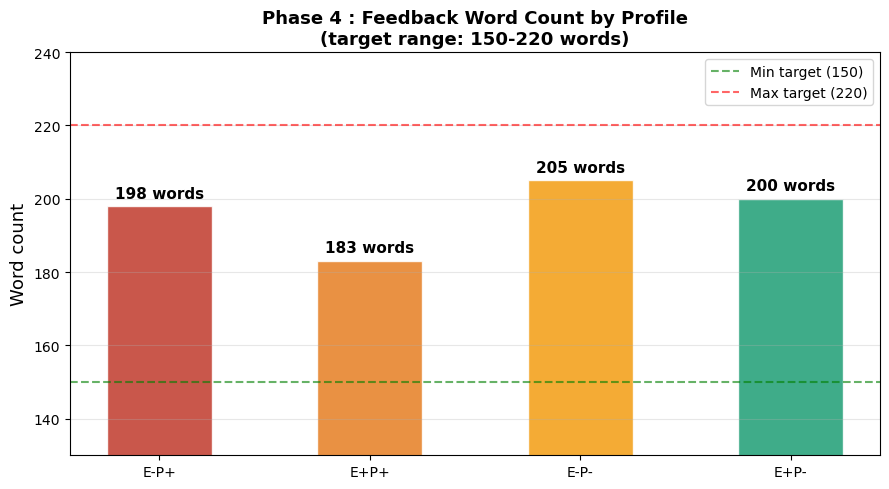

In [13]:
import matplotlib.pyplot as plt

df_feedback = pd.read_csv('outputs/feedback_final.csv')

profiles  = df_feedback['profil'].tolist()
wc        = df_feedback['word_count'].tolist()
colors_fb = ['#C0392B', '#E67E22', '#F39C12', '#1D9E75']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(profiles, wc, color=colors_fb, alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(150, color='green',  linestyle='--', alpha=0.6, label='Min target (150)')
ax.axhline(220, color='red',    linestyle='--', alpha=0.6, label='Max target (220)')
ax.bar_label(bars, fmt='%d words', padding=4, fontsize=11, fontweight='bold')
ax.set_ylabel('Word count', fontsize=13)
ax.set_ylim(130, 240)
ax.set_title('Phase 4 : Feedback Word Count by Profile\n(target range: 150-220 words)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/canva/fig_feedback_wordcount.png', dpi=200, bbox_inches='tight')
plt.show()